In [6]:
import matplotlib.pyplot as plt 
import json 
import numpy as np 
import pandas as pd
import os 
json_data_stability_2 = "Ni_Cr_json_data/Optimization_v2/Stability_complete_Ni_Cr_v2_fixed.json"
json_data_ECSA_v2 = "Ni_Cr_json_data/Optimization_v2/ECSA_complete_Ni_Cr_v2_fixed.json"
json_data_EIS_v2 = "Ni_Cr_json_data/Optimization_v2/EIS_complete_Ni_Cr_v2_fixed.json"

with open(json_data_stability_2, 'r') as infile:
    stability_dict_v2 = json.load(infile)

with open(json_data_ECSA_v2, 'r') as infile:
    ECSA_dict_v2 = json.load(infile)

with open(json_data_EIS_v2, 'r') as infile:
    EIS_dict_v2 = json.load(infile)

json_data_stability_1 = "Ni_Cr_json_data/Optimization_v1/Stability_complete_Ni_Cr_v1.json"
json_data_ECSA_v1 = "Ni_Cr_json_data/Optimization_v1/ECSA_complete_Ni_Cr_v1.json"
json_data_EIS_v1 = "Ni_Cr_json_data/Optimization_v1/EIS_complete_Ni_Cr_v1.json"

with open(json_data_stability_1, 'r') as infile:
    stability_dict_v1 = json.load(infile)

with open(json_data_ECSA_v1, 'r') as infile:
    ECSA_dict_v1 = json.load(infile)

with open(json_data_EIS_v1, 'r') as infile:
    EIS_dict_v1 = json.load(infile)

jsons_Ni_Mo = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/Ni_Mo_paper/Complete_data_paolo_jonas_run/Complete_datasets_detailed"
stability_dicts = {}

for json_file in os.listdir(jsons_Ni_Mo):
    if "Stability" in json_file:
        file_path = os.path.join(jsons_Ni_Mo, json_file)
        
        with open(file_path, 'r') as infile:
            stability_dict = json.load(infile)
        
        # Merge dictionaries
        stability_dicts.update(stability_dict)
# Also here load the NiMo datasets 




# Create simple df such that we can compare

In [7]:
rows = []

# Note all the overpotentials are IR corrected ... 
if 1 == 2:
    for experiment, exp_data in stability_dict_v1.items():
        params = exp_data['ML optimization params']
        timestamp = exp_data["timestamp"]
        R_100 = exp_data['Cycling results']['Resistance at 100 mA/cm2']

        overpotentials_1 = exp_data['Cycling results']["Overpotentials at 1 mA/cm2"]
        overpotentials_10 = exp_data['Cycling results']["Overpotentials at 10 mA/cm2"]
        overpotentials_100 = exp_data['Cycling results']["Overpotentials at 100 mA/cm2"]

        measured_current_density_100 = exp_data['Cycling results']["Measured current density at 100 mA/cm2"]
        # Mean resistance at 100 mA/cm2
        R_100_mean = np.mean(R_100)
        overpotentials_mean_1 = np.mean(overpotentials_1)
        overpotentials_mean_10 = np.mean(overpotentials_10)
        overpotentials_mean_100 = np.mean(overpotentials_100)
        current_density_100_mean = np.mean(measured_current_density_100)
        # Convert params to numeric where possible
        params_numeric = {
            k: float(v) if v is not None else np.nan
            for k, v in params.items()
        }
        
        row = {
            'experiment': experiment,
            'timestamp' : timestamp, 
            'R_100_mean': R_100_mean,
            
            'OP @ -1 mA/cm2 mean (mV)' : overpotentials_mean_1,
            'OP @ -10 mA/cm2 mean (mV)' : overpotentials_mean_10,
            'OP @ -100 mA/cm2 mean (mV)' : overpotentials_mean_100,
            'Measured I (mA/cm2) @ 100' : current_density_100_mean,
            **params_numeric
        }
        rows.append(row)



# Mapping for liquid parameters: scaling + renaming
liquid_mapping = {
    'liquid4': {
        'scale': 1 / 15,
        'new_name': 'Concentrations H2SO4 [mol/L]'
    },
    'liquid5': {
        'scale': 0.4 / 15,
        'new_name': 'Concentrations NiSO4 [mol/L]'
    },
    'liquid6': {
        'scale': 0.4 / 15,
        'new_name': 'Concentrations CrCl3 [mol/L]'
    }
}

for experiment, exp_data in stability_dict_v2.items():
    params = exp_data['ML optimization params']
    timestamp = exp_data["timestamp"]

    R_100 = exp_data['Cycling results']['Resistance at 100 mA/cm2']
    overpotentials_1 = exp_data['Cycling results']["Overpotentials at 1 mA/cm2"]
    overpotentials_10 = exp_data['Cycling results']["Overpotentials at 10 mA/cm2"]
    overpotentials_100 = exp_data['Cycling results']["Overpotentials at 100 mA/cm2"]
    measured_current_density_100 = exp_data['Cycling results']["Measured current density at 100 mA/cm2"]

    # Means
    R_100_mean = np.mean(R_100)
    overpotentials_mean_1 = np.mean(overpotentials_1)
    overpotentials_mean_10 = np.mean(overpotentials_10)
    overpotentials_mean_100 = np.mean(overpotentials_100)
    current_density_100_mean = np.mean(measured_current_density_100)

    # Convert params to numeric, apply scaling + renaming for liquids
    params_numeric = {}

    for k, v in params.items():
        if v is None:
            val = np.nan
        else:
            val = float(v)

        if k in liquid_mapping:
            val = val * liquid_mapping[k]['scale']
            params_numeric[liquid_mapping[k]['new_name']] = val
        else:
            params_numeric[k] = val

    # Final row
    row = {
        'experiment': experiment,
        'timestamp': timestamp,
        'R_100_mean': R_100_mean,
        'OP @ -1 mA/cm2 mean (mV)': overpotentials_mean_1,
        'OP @ -10 mA/cm2 mean (mV)': overpotentials_mean_10,
        'OP @ -100 mA/cm2 mean (mV)': overpotentials_mean_100,
        'Measured I (mA/cm2) @ 100': current_density_100_mean,
        **params_numeric
    }

    rows.append(row)

# Create DataFrame
df_NiCr = pd.DataFrame(rows)
df_NiCr = df_NiCr.sort_values(by='timestamp')
df_NiCr = df_NiCr.reset_index(drop=True)
df_NiCr['time_idx'] = df_NiCr.index
print(df_NiCr.columns)

rows = []
# ## NiMo
for experiment, exp_data in stability_dicts.items():
    params = exp_data['ML optimization params']
    timestamp = exp_data["timestamp"]
    R_100 = exp_data['Cycling results']['Resistance at 100 mA/cm2']

    overpotentials_1 = exp_data['Cycling results']["Overpotentials at 1 mA/cm2"]
    overpotentials_10 = exp_data['Cycling results']["Overpotentials at 10 mA/cm2"]
    overpotentials_100 = exp_data['Cycling results']["Overpotentials at 100 mA/cm2"]

    measured_current_density_100 = exp_data['Cycling results']["Measured current density at 100 mA/cm2"]
    # Mean resistance at 100 mA/cm2
    R_100_mean = np.mean(R_100)
    overpotentials_mean_1 = np.mean(overpotentials_1)
    overpotentials_mean_10 = np.mean(overpotentials_10)
    overpotentials_mean_100 = np.mean(overpotentials_100)
    current_density_100_mean = np.mean(measured_current_density_100)
    # Convert params to numeric where possible
    params_numeric = {
        k: float(v) if v is not None else np.nan
        for k, v in params.items()
    }
    
    row = {
        'experiment': experiment,
        'timestamp' : timestamp, 
        'R_100_mean': R_100_mean,
        
        'OP @ -1 mA/cm2 mean (mV)' : overpotentials_mean_1,
        'OP @ -10 mA/cm2 mean (mV)' : overpotentials_mean_10,
        'OP @ -100 mA/cm2 mean (mV)' : overpotentials_mean_100,
        'Measured I (mA/cm2) @ 100' : current_density_100_mean,
        **params_numeric
    }
    rows.append(row)
#plt.plot(df['Overpotentials_10_mean'].to_numpy())

# Create DataFrame
df_NiMo = pd.DataFrame(rows)
df_NiMo = df_NiMo.sort_values(by='OP @ -100 mA/cm2 mean (mV)')

df_NiMo['time_idx'] = df_NiMo.index

# Remove large resistance outliers
df_NiCr = df_NiCr[np.abs(df_NiCr['R_100_mean']) <= 50]

# Sort by OP at -100 mA/cm2
df_NiCr = df_NiCr.sort_values(by='OP @ -100 mA/cm2 mean (mV)')

# Reset index
df_NiCr = df_NiCr.reset_index(drop=True)

# Recreate time index if needed
df_NiCr['time_idx'] = df_NiCr.index

# Remove large resistance outliers
df_NiMo = df_NiMo[np.abs(df_NiMo['R_100_mean']) <= 50]

# Sort by OP at -100 mA/cm2
df_NiMo = df_NiMo.sort_values(by='OP @ -100 mA/cm2 mean (mV)')

# Reset index
df_NiMo = df_NiMo.reset_index(drop=True)

df_NiMo['time_idx'] = df_NiMo.index


Index(['experiment', 'timestamp', 'R_100_mean', 'OP @ -1 mA/cm2 mean (mV)',
       'OP @ -10 mA/cm2 mean (mV)', 'OP @ -100 mA/cm2 mean (mV)',
       'Measured I (mA/cm2) @ 100', 'Deposition time [s]',
       'Deposition current density [mA/cm2]', 'Temperature_deposition [C]',
       'water', 'Concentrations H2SO4 [mol/L]', 'Concentrations NiSO4 [mol/L]',
       'Concentrations CrCl3 [mol/L]', 'time_idx'],
      dtype='object')


# Get the experiments with the lowest values

Index(['experiment', 'timestamp', 'R_100_mean', 'OP @ -1 mA/cm2 mean (mV)',
       'OP @ -10 mA/cm2 mean (mV)', 'OP @ -100 mA/cm2 mean (mV)',
       'Measured I (mA/cm2) @ 100', 'Deposition time [s]',
       'Deposition current density [mA/cm2]', 'Temperature_deposition [C]',
       'Concentrations NiSO4 [mol/L]', 'Concentrations Na2Mo [mol/L]',
       'Concentrations H2SO4 [mol/L]', 'time_idx'],
      dtype='object')
1.8440074362116312 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/16_03_2026_17_49__exp_202
1.82921408528545 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_00_12__exp_150
1.802035455235619 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/17_03_2026_20_38__exp_219
1.674325523574

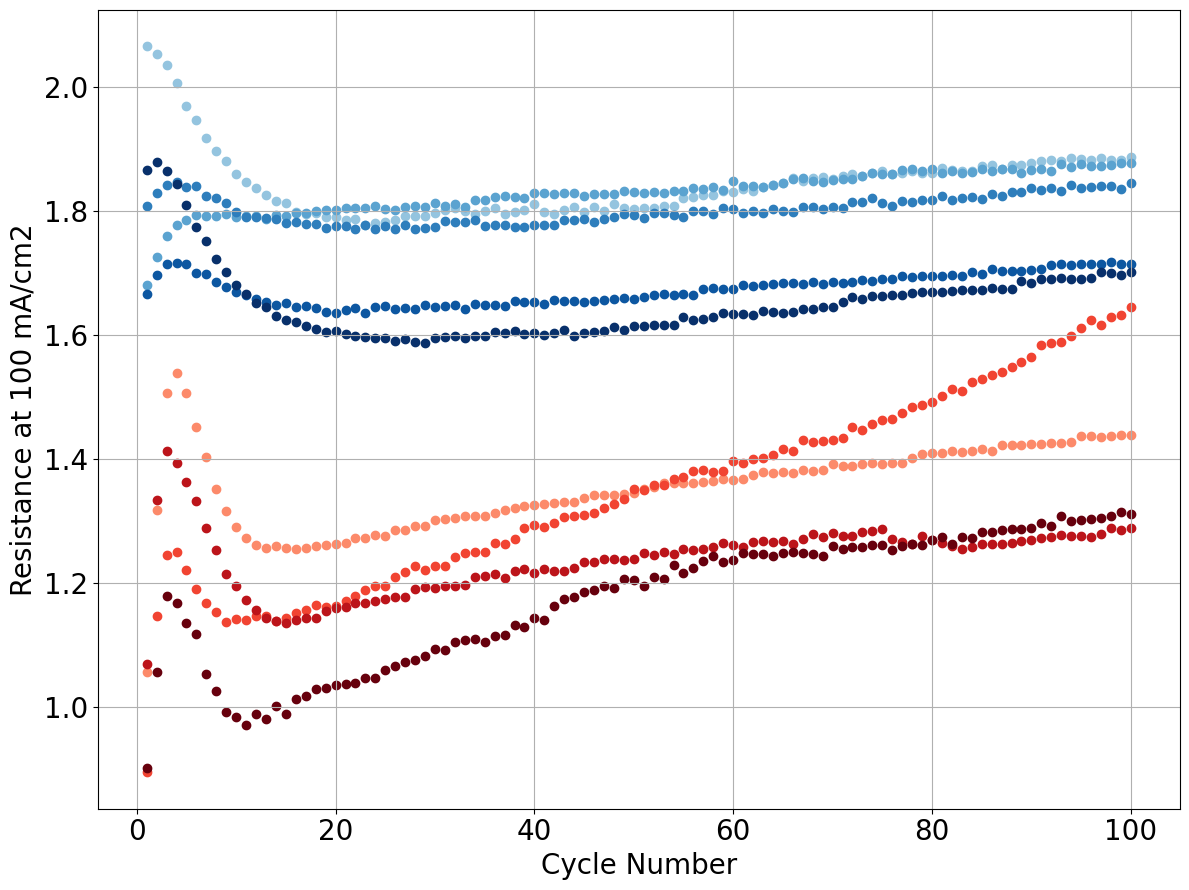

37.33638226279991 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/16_03_2026_17_49__exp_202
50.525585239135786 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_00_12__exp_150
49.788809204794774 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/17_03_2026_20_38__exp_219
48.5465323857886 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_05_42__exp_153
47.47699944991029 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_07_39__exp_154


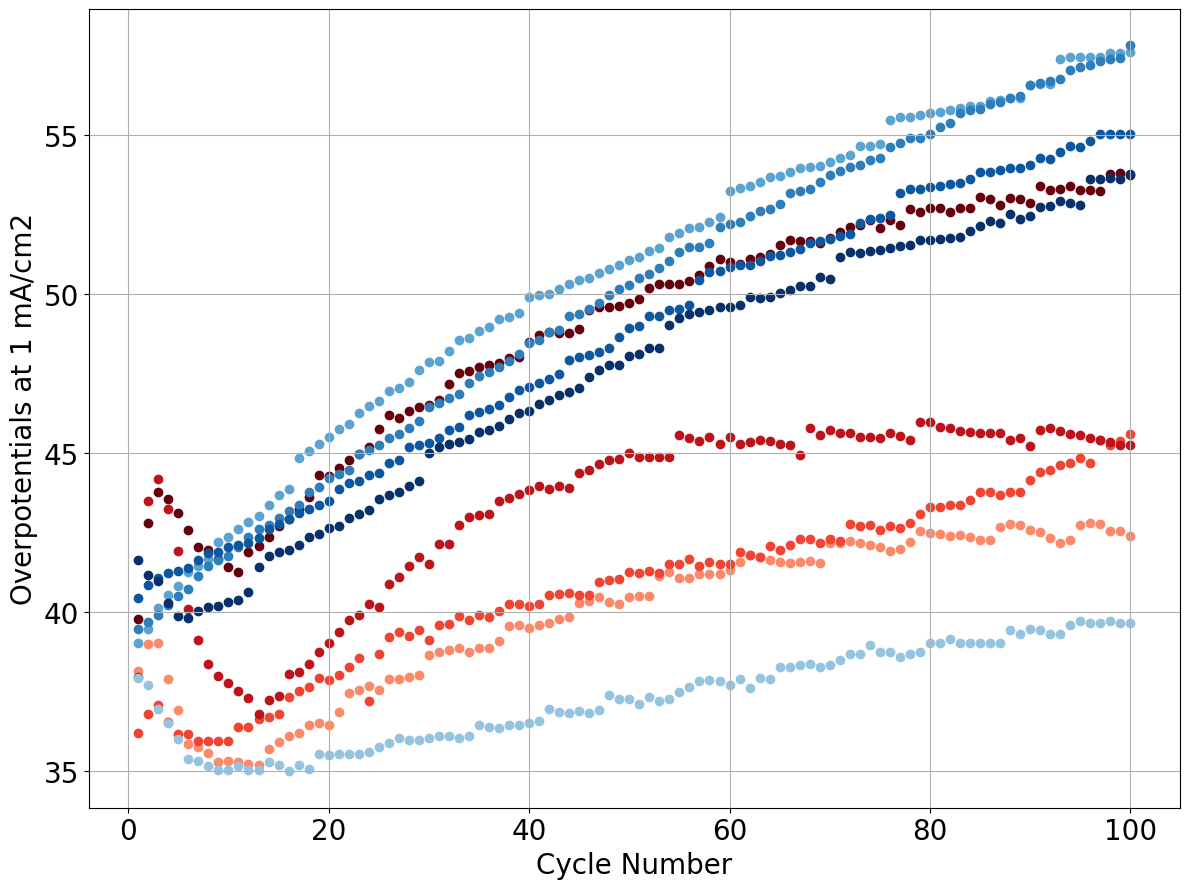

73.7832763469166 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/16_03_2026_17_49__exp_202
78.59142017200003 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_00_12__exp_150
78.08695963274971 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/17_03_2026_20_38__exp_219
71.14337955441418 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_05_42__exp_153
70.29734025986482 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_07_39__exp_154


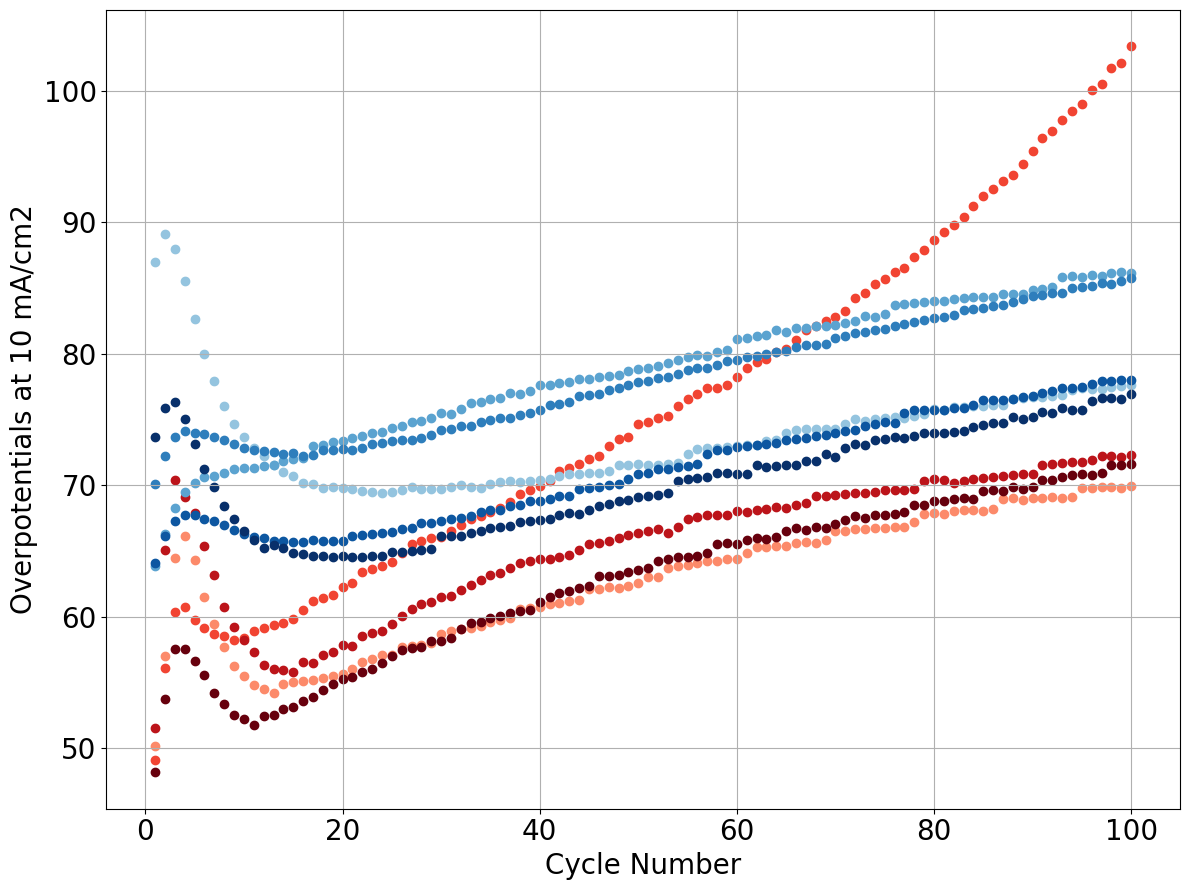

184.39314150000354 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/16_03_2026_17_49__exp_202
182.9215572477493 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_00_12__exp_150
180.19699746306685 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/17_03_2026_20_38__exp_219
167.4405932168502 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_05_42__exp_153
165.1141284079257 /Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Cr_Optimization/Ni_Cr_optimization_26_1_2026 CatBot 21 fixed/13_02_2026_07_39__exp_154


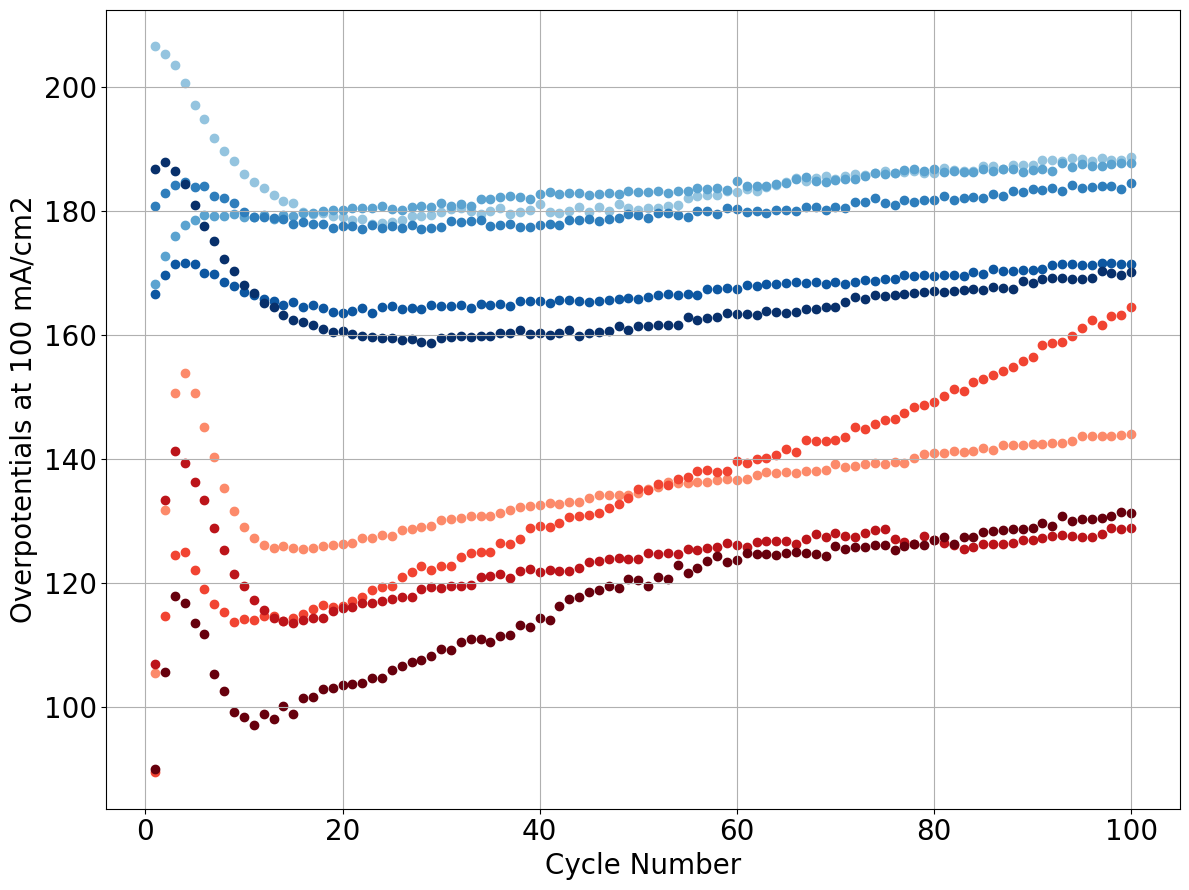

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Get lowest 10 experiments
# ----------------------------
lowest_10_experiments_NiMo = (
    df_NiMo.sort_values(by='OP @ -100 mA/cm2 mean (mV)')
    .tail(4)['experiment']
    .tolist()
)


targets = ['Resistance at 100 mA/cm2', "Overpotentials at 1 mA/cm2", "Overpotentials at 10 mA/cm2", "Overpotentials at 100 mA/cm2"]



lowest_10_experiments_NiCr = (
    df_NiCr.sort_values(by='OP @ -100 mA/cm2 mean (mV)')
    .tail(5)['experiment']
    .tolist()
)

# =====================================================
# ===============  NiMo  (Blues)  =====================
# =====================================================
for target in targets:
    plt.figure(figsize=(12,9))

    reds = plt.cm.Reds(np.linspace(0.4, 1, len(lowest_10_experiments_NiMo)))

    blues = plt.cm.Blues(np.linspace(0.4, 1, len(lowest_10_experiments_NiCr)))

    for color, experiment in zip(reds, lowest_10_experiments_NiMo):
        data = stability_dicts[experiment]
        OP_100 = np.abs(data['Cycling results'][target])
        plt.scatter(np.arange(1 , 1 + len(OP_100)), OP_100, color=color)
        

    for color, experiment in zip(blues, lowest_10_experiments_NiCr):
        
        # Handle v1 / v2 dictionaries
        if experiment in stability_dict_v1:
            data = stability_dict_v1[experiment]
        else:
            data = stability_dict_v2[experiment]
        
        OP_100 = np.abs(data['Cycling results'][target])
        print(np.mean(OP_100),data['exp location PC'])
        plt.scatter(np.arange(1 , 1 + len(OP_100)), OP_100, color=color)

    plt.xlabel("Cycle Number", fontsize=20)
    plt.ylabel(target, fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Print the best NiMo catalysts

In [58]:
# Make pandas display wider
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)

# Get top 3 best (lowest overpotential) NiMo experiments
best_3_experiments_NiMo = (
    df_NiMo.sort_values(by='OP @ -10 mA/cm2 mean (mV)', ascending=True)
    .tail(3)   # use head for BEST (lowest)
)



print("\nOverpotential Comparison:")
print(
    best_3_experiments_NiMo[
        [     'Deposition time [s]',
            'OP @ -1 mA/cm2 mean (mV)',
            'OP @ -10 mA/cm2 mean (mV)',
            'OP @ -100 mA/cm2 mean (mV)'
        ]
    ].to_string(index=False)
)
print(best_3_experiments_NiMo.columns)

columns_to_see = ['Deposition time [s]', 
 'Deposition current density [mA/cm2]', 
 'Temperature_deposition [C]', 
 'Concentrations NiSO4 [mol/L]', 
 'Concentrations Na2Mo [mol/L]', 
 'Concentrations H2SO4 [mol/L]']


Overpotential Comparison:
 Deposition time [s]  OP @ -1 mA/cm2 mean (mV)  OP @ -10 mA/cm2 mean (mV)  OP @ -100 mA/cm2 mean (mV)
               148.6                -37.796926                 -64.522094                 -140.862581
               533.5                -39.955734                 -62.770513                 -135.482540
               405.5                -48.827770                 -62.673115                 -117.378559
Index(['experiment', 'timestamp', 'R_100_mean', 'OP @ -1 mA/cm2 mean (mV)', 'OP @ -10 mA/cm2 mean (mV)', 'OP @ -100 mA/cm2 mean (mV)', 'Measured I (mA/cm2) @ 100', 'Deposition time [s]', 'Deposition current density [mA/cm2]', 'Temperature_deposition [C]', 'Concentrations NiSO4 [mol/L]', 'Concentrations Na2Mo [mol/L]', 'Concentrations H2SO4 [mol/L]', 'time_idx'], dtype='object')


print(stability_dicts)